# Complementary filter

Conceptually, sensor fusion consists on estimating a magnitude levering data from different sensors. In this case, the magnitudes of interest are the angles with respect to each axis, which will be later used to remove gravity from linear acceleration by trasforming the g vector to the device's reference frame and substracting it. 

The complementary filter is a simple way to do this, based on different characteristics of the sensors:

* Gyroscope: good short-term stability, but drifts in the long term.
* Accelerometer: good long-term stability, but noisy in the short term.

As shown in (3), on continuous time the idea would be to apply a low-pass effect on angle the computed from accelerometer data and a high-pass effect on the integrated gyroscope data. On discrete time, this can be implemented with the following formula:

$$
\theta_t = \alpha (\theta_{t-1} + \omega_{t} \cdot \Delta t) + (1 - \alpha) \theta_{acc, t}
$$

Where $0 < \alpha \leq 1$ is a tuning parameter, and: $\alpha = \frac{\tau}{\tau + \Delta t}$, where $\tau$ is the time constant of the filter and $\Delta t$ is the sampling period.

In 3D space, angles from the accelerometer can be computed with the following formulas:

  $$
  \theta_{x} = \arctan\left(\frac{a_x}{\sqrt{a_y^2 + a_z^2}}\right)
  $$

  $$
  \theta_{y} = \arctan\left(\frac{a_y}{\sqrt{a_x^2 + a_z^2}}\right)
  $$

  $$    
  \theta_{z} = \arctan\left(\frac{\sqrt{a_x^2 + a_y^2}}{a_z}\right) \quad \text{Reference: 1g }
  $$
  
These formulas assume that gravity is the only force acting on the device, which is not the case in this application. A possible solution could involve changing alpha to favor the gyroscope data more heavily when the device is in motion, and weigh the accelerometer more when the device is relatively stationary. A simple (but not perfect) way to detect motion is to check that: $ | ||\mathbf{a}|| - tol | > g $, where *tol* is a tolerance value that can be tuned.  

Sources:

(1) ["The balance filter" by Shane Colton](../../docs/misc/Motion%20filters.pdf)

(2) ["Using an Accelerometer for inclination sensing" application note by Christopher Fisher](../../docs/misc/Accelerometer%20inclination.pdf)

(3) [Drone Control and the Complementary Filter by Brian Douglas](https://www.youtube.com/watch?v=whSw42XddsU)


# Setup

In [53]:
from signal_utils import IMUSampleReader, IMUSampleTimeSeriesPlotter
import matplotlib.pyplot as plt
import numpy as np
import math

CAPTURE_PATH = "../exercise-reception/capture-apr-28-2026/pull-ups-1.csv"

# CAPTURE_PATH = "../1-calibration/output/positive-z-up-calibrated.csv"

reader = IMUSampleReader()
rawSamplestimeSeriesPlotter = IMUSampleTimeSeriesPlotter()

## Estimation of angles from accelerometer data

In [54]:
samples = reader.read(CAPTURE_PATH)

computeAngleX = (
    lambda ax, ay, az: 180 / np.pi * math.atan2(ax, math.sqrt(ay**2 + az**2))
)
computeAngleY = (
    lambda ax, ay, az: 180 / np.pi * math.atan2(ay, math.sqrt(ax**2 + az**2))
)
computeAngleZ = (
    lambda ax, ay, az: 180 / np.pi * math.atan2(math.sqrt(ax**2 + ay**2), az)
)

angleXAccel = np.array([computeAngleX(ax, ay, az) for ax, ay, az in zip(samples["a"]["x"], samples["a"]["y"], samples["a"]["z"])])  # type: ignore
angleYAccel = np.array([computeAngleY(ax, ay, az) for ax, ay, az in zip(samples["a"]["x"], samples["a"]["y"], samples["a"]["z"])])  # type: ignore
angleZAccel = np.array([computeAngleZ(ax, ay, az) for ax, ay, az in zip(samples["a"]["x"], samples["a"]["y"], samples["a"]["z"])])  # type: ignore

## Estimation from gyroscope data

In [55]:
SAMPLING_FREQUENCY = 30  # Hz
dt = 1 / SAMPLING_FREQUENCY

integrateEuler = lambda prev, curr, step: prev + curr * step

signalLength = len(samples["w"]["roll"])  # type: ignore
angleXGyro = np.zeros(signalLength)  # type: ignore
angleYGyro = np.zeros(signalLength)  # type: ignore
angleZGyro = np.zeros(signalLength)  # type: ignore
for i in range(1, signalLength):  # type: ignore
    angleXGyro[i] = integrateEuler(angleXGyro[i - 1], samples["w"]["roll"][i], dt)  # type: ignore
    angleYGyro[i] = integrateEuler(angleYGyro[i - 1], samples["w"]["pitch"][i], dt)  # type: ignore
    angleZGyro[i] = integrateEuler(angleZGyro[i - 1], samples["w"]["yaw"][i], dt)  # type: ignore

## Complementary filter

In [ ]:
alpha = 0.95
angleXComplementary = alpha * angleXGyro + (1 - alpha) * angleXAccel
angleYComplementary = alpha * angleYGyro + (1 - alpha) * angleYAccel
angleZComplementary = alpha * angleZGyro + (1 - alpha) * angleZAccel  # valid?

## Plotting results

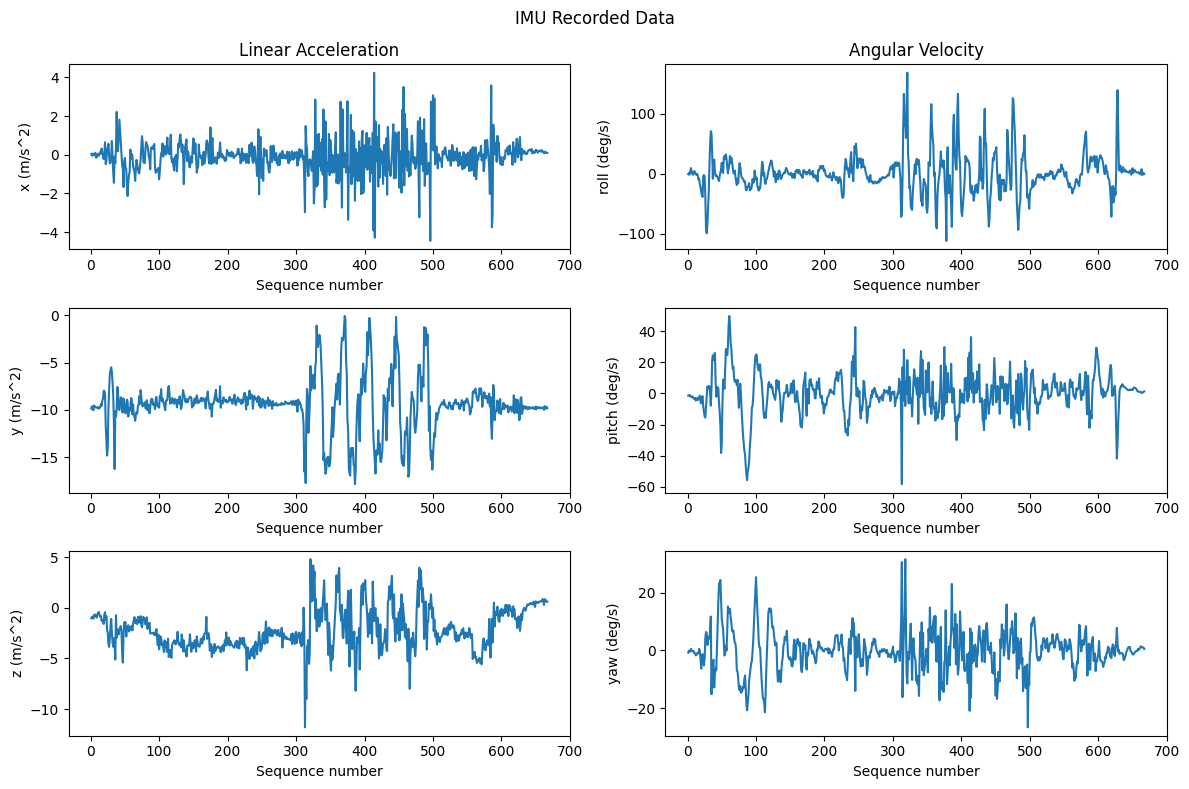

In [57]:
rawSamplestimeSeriesPlotter.plot(samples)

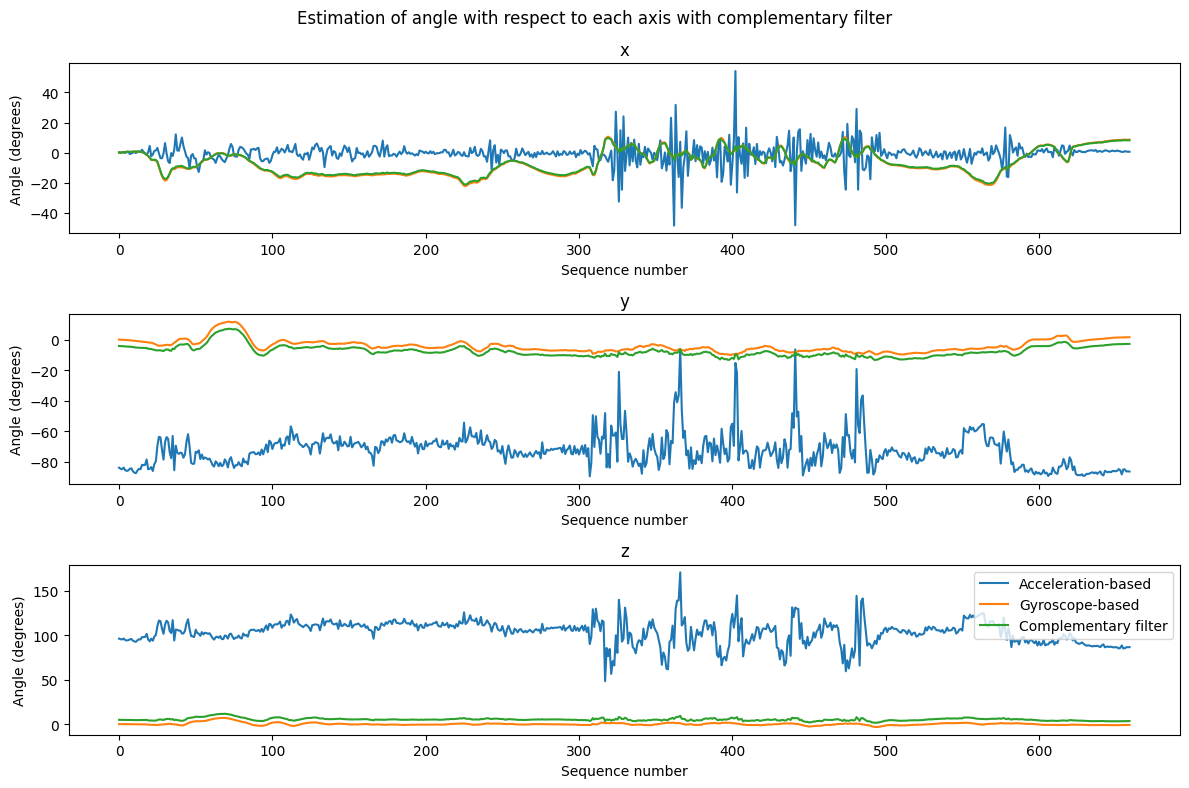

In [58]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8))

fig.suptitle("Estimation of angle with respect to each axis with complementary filter")

axes[0].plot(angleXAccel, label="Acceleration-based")
axes[0].plot(angleXGyro, label="Gyroscope-based")
axes[0].plot(angleXComplementary, label="Complementary filter")
axes[0].set_ylabel("Angle (degrees)")
axes[0].set_xlabel("Sequence number")
axes[0].set_title("x")

axes[1].plot(angleYAccel, label="Acceleration-based")
axes[1].plot(angleYGyro, label="Gyroscope-based")
axes[1].plot(angleYComplementary, label="Complementary filter")
axes[1].set_ylabel("Angle (degrees)")
axes[1].set_xlabel("Sequence number")
axes[1].set_title("y")

axes[2].plot(angleZAccel, label="Acceleration-based")
axes[2].plot(angleZGyro, label="Gyroscope-based")
axes[2].plot(angleZComplementary, label="Complementary filter")
axes[2].set_ylabel("Angle (degrees)")
axes[2].set_xlabel("Sequence number")
axes[2].set_title("z")

plt.legend(loc="upper right")
plt.tight_layout()
plt.show()